# SmartCart Clustering System

In [8]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

In [9]:
customers_data=pd.read_csv("../data/smartcart_customers.csv")

In [10]:
customers_data.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,172,88,88,3,8,10,4,7,0,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,2,1,6,2,1,1,2,5,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,111,21,42,1,8,2,10,4,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,10,3,5,2,2,0,4,6,0,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,46,27,15,5,5,3,6,5,0,0


# Handling Missing Data

In [11]:
customers_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 22 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

In [12]:
customers_data.describe()

,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response
count,2240.000000,2240.000000,2216.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000
mean,5592.159821,1968.805804,52247.251354,0.444196,0.506250,49.109375,303.935714,26.302232,166.950000,37.525446,27.062946,44.021875,2.325000,4.084821,2.662054,5.790179,5.316518,0.009375,0.149107
std,3246.662198,11.984069,25173.076661,0.538398,0.544538,28.962453,336.597393,39.773434,225.715373,54.628979,41.280498,52.167439,1.932238,2.778714,2.923101,3.250958,2.426645,0.096391,0.356274
min,0.000000,1893.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2828.250000,1959.000000,35303.000000,0.000000,0.000000,24.000000,23.750000,1.000000,16.000000,3.000000,1.000000,9.000000,1.000000,2.000000,0.000000,3.000000,3.000000,0.000000,0.000000
50%,5458.500000,1970.000000,51381.500000,0.000000,0.000000,49.000000,173.500000,8.000000,67.000000,12.000000,8.000000,24.000000,2.000000,4.000000,2.000000,5.000000,6.000000,0.000000,0.000000
75%,8427.750000,1977.000000,68522.000000,1.000000,1.000000,74.000000,504.250000,33.000000,232.000000,50.000000,33.000000,56.000000,3.000000,6.000000,4.000000,8.000000,7.000000,0.000000,0.000000
max,11191.000000,1996.000000,666666.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,263.000000,362.000000,15.000000,27.000000,28.000000,13.000000,20.000000,1.000000,1.000000


In [13]:
customers_data.isnull().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
Complain                0
Response                0
dtype: int64

In [14]:
imp=SimpleImputer(strategy="median")
customers_data["Income"]=imp.fit_transform(customers_data[["Income"]]).ravel()

In [15]:
customers_data.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,172,88,88,3,8,10,4,7,0,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,2,1,6,2,1,1,2,5,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,111,21,42,1,8,2,10,4,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,10,3,5,2,2,0,4,6,0,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,46,27,15,5,5,3,6,5,0,0


In [16]:
customers_data.isnull().sum()

ID                     0
Year_Birth             0
Education              0
Marital_Status         0
Income                 0
Kidhome                0
Teenhome               0
Dt_Customer            0
Recency                0
MntWines               0
MntFruits              0
MntMeatProducts        0
MntFishProducts        0
MntSweetProducts       0
MntGoldProds           0
NumDealsPurchases      0
NumWebPurchases        0
NumCatalogPurchases    0
NumStorePurchases      0
NumWebVisitsMonth      0
Complain               0
Response               0
dtype: int64

# Feature Engineering

In [17]:
customers_data["Age"]=2026-customers_data["Year_Birth"]

In [18]:
customers_data.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,88,88,3,8,10,4,7,0,1,69
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,1,6,2,1,1,2,5,0,0,72
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,21,42,1,8,2,10,4,0,0,61
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,3,5,2,2,0,4,6,0,0,42
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,27,15,5,5,3,6,5,0,0,45


In [19]:
customers_data["Dt_Customer"]=pd.to_datetime(customers_data["Dt_Customer"],dayfirst=True)
reference_date=customers_data["Dt_Customer"].max()
customers_data["Customer_Tenure_Days"]=(reference_date-customers_data["Dt_Customer"]).dt.days

In [20]:
customers_data.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,88,3,8,10,4,7,0,1,69,663
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,6,2,1,1,2,5,0,0,72,113
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,42,1,8,2,10,4,0,0,61,312
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,5,2,2,0,4,6,0,0,42,139
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,15,5,5,3,6,5,0,0,45,161


In [21]:
customers_data["Total_Spending"]=customers_data["MntWines"]+customers_data["MntFruits"]+customers_data["MntMeatProducts"]+customers_data["MntFishProducts"]+customers_data["MntGoldProds"]+customers_data["MntSweetProducts"]
customers_data["Total_Children"]=customers_data["Kidhome"]+customers_data["Teenhome"]

In [22]:
customers_data.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_Spending,Total_Children
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,8,10,4,7,0,1,69,663,1617,0
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,1,1,2,5,0,0,72,113,27,2
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,8,2,10,4,0,0,61,312,776,0
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,2,0,4,6,0,0,42,139,53,1
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,5,3,6,5,0,0,45,161,422,1


In [23]:
customers_data["Education"]=customers_data["Education"].replace({
    "Basic":"Undergraduate",
    "2n Cycle":"Undergraduate",
    "Graduation":"Graduate",
    "Master":"Postgraduate",
    "PhD":"Postgraduate"
})
customers_data["Education"]=customers_data["Education"].replace({
    "Undegraduate":"Undergraduate",
})
customers_data["Education"].value_counts()

Education
Graduate         1127
Postgraduate      856
Undergraduate     257
Name: count, dtype: int64

In [24]:
customers_data["Living_With"]=customers_data["Marital_Status"].replace({
    "Married":"Partner",
    "Together":"Partner",
    "Single":"Alone",
    "Divorced":"Alone",
    "Widow":"Alone",
    "Absurd":"Alone",
    "YOLO":"Alone"
})
customers_data["Living_With"].value_counts()

Living_With
Partner    1444
Alone       796
Name: count, dtype: int64

# Dropping Columns

In [25]:
cols=["ID","Year_Birth","Marital_Status","Kidhome","Teenhome","Dt_Customer"]
spending_cols=["MntWines","MntFruits","MntGoldProds","MntMeatProducts","MntFishProducts","MntSweetProducts"]
drop_cols=cols+spending_cols
customers_data_cleaned=customers_data.drop(columns=drop_cols,axis=1)
customers_data_cleaned.shape

(2240, 15)

# Outliers Detection

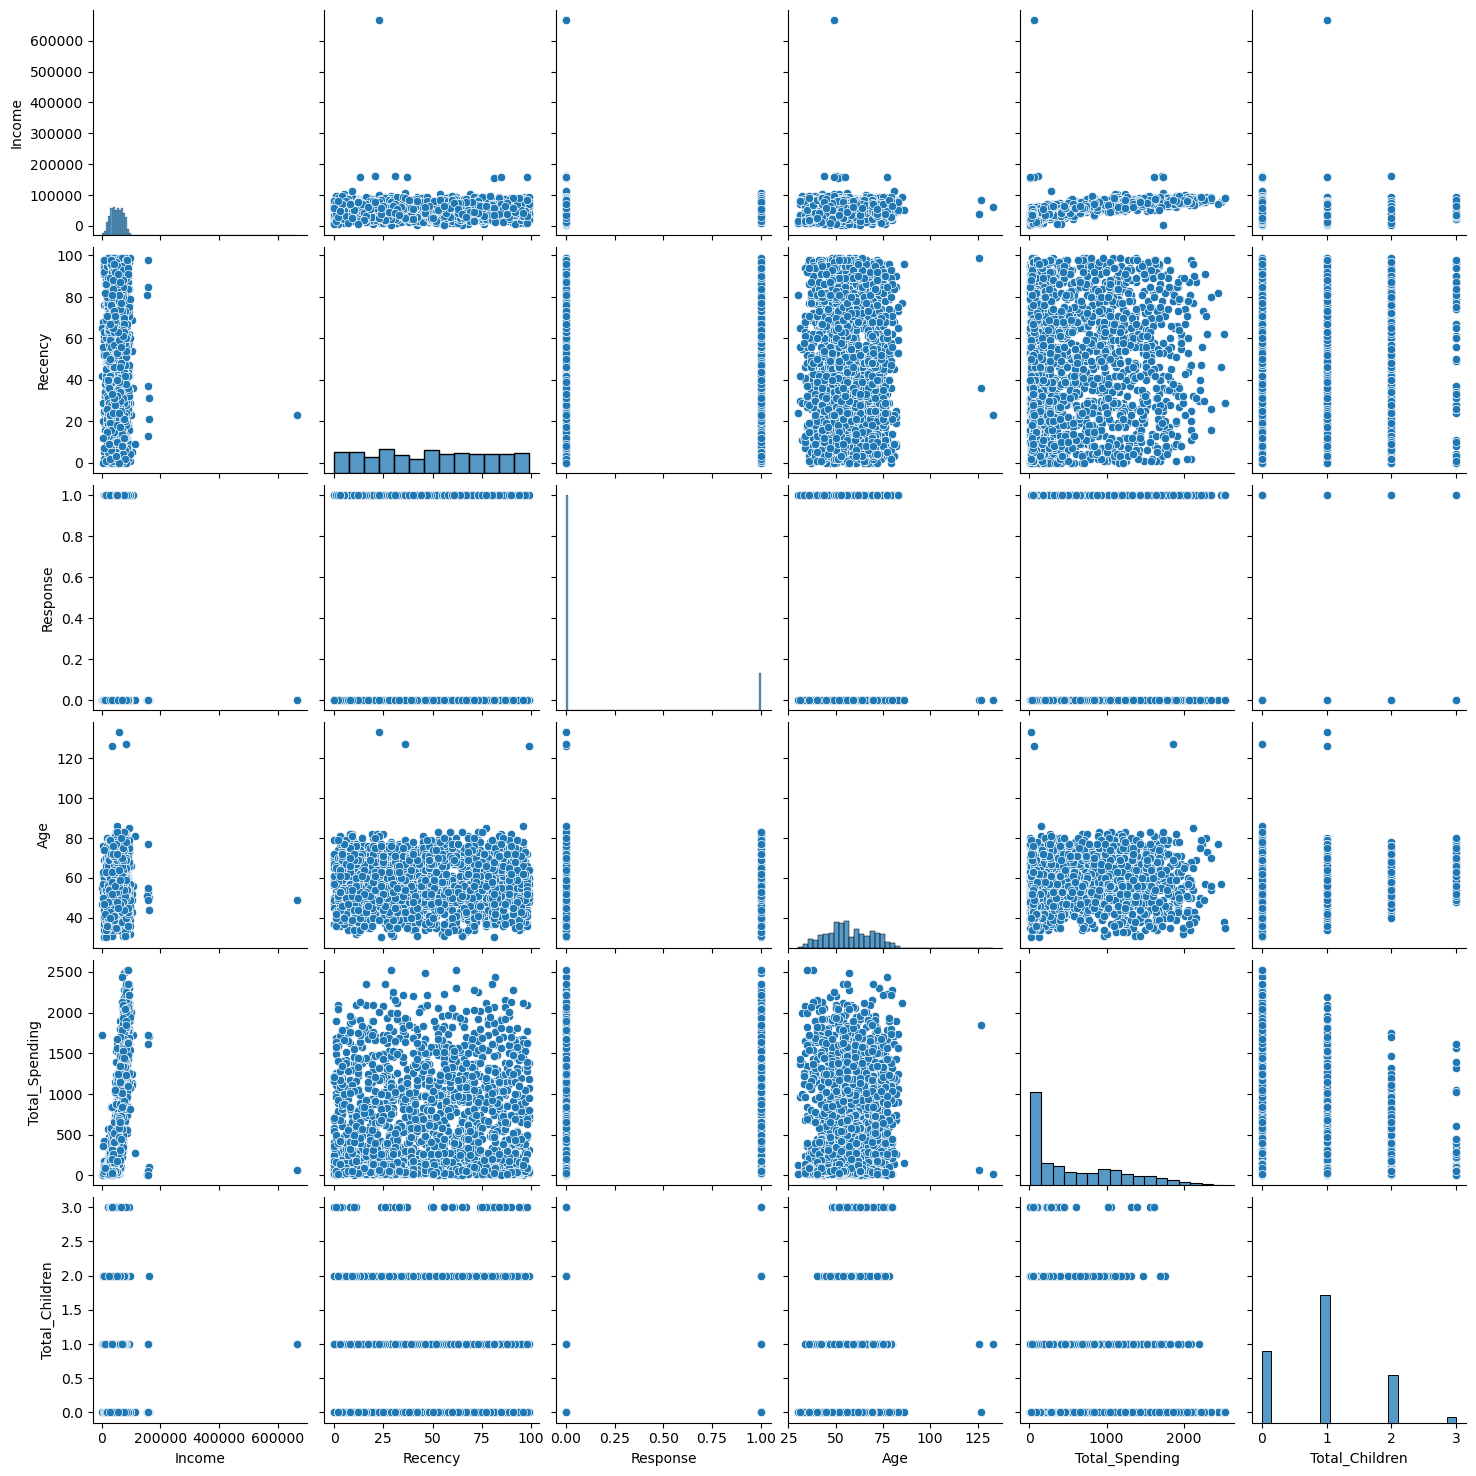

In [26]:
cols=["Income","Recency","Response","Age","Total_Spending","Total_Children"]
sns.pairplot(customers_data[cols])

In [27]:
print(f"Data size with outliers : {len(customers_data)}")
customers_data=customers_data[customers_data["Age"]<90]
customers_data=customers_data[customers_data["Income"]<600000]
print(f"Data size without outliers : {len(customers_data)}")


Data size with outliers : 2240
Data size without outliers : 2236


# HeatMap

In [28]:
customers_data_cleaned=customers_data.drop(columns=drop_cols,axis=1)
corr=customers_data_cleaned.corr(numeric_only=True)

<Axes: title={'center': 'Features Interrelationship'}>

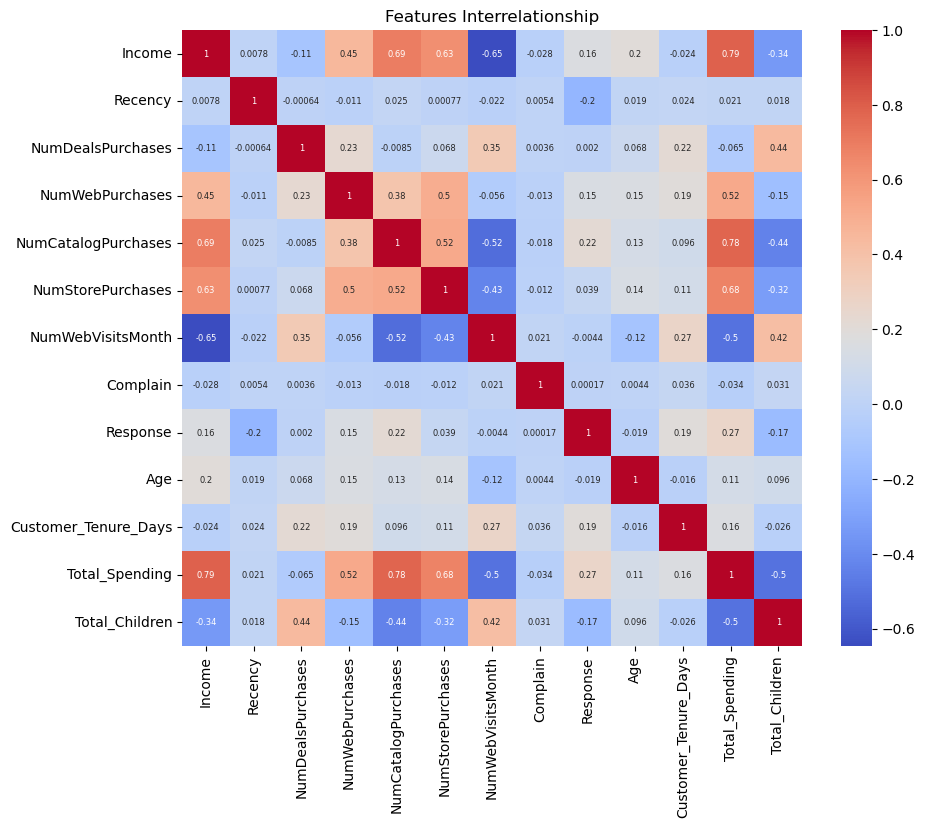

In [29]:
plt.figure(figsize=(10,8))
plt.title("Features Interrelationship")
sns.heatmap(corr,annot=True,annot_kws={"size":6},cmap="coolwarm")

# Feature Encoding

In [30]:
from sklearn.preprocessing import OneHotEncoder

In [31]:
ohe=OneHotEncoder()
cat_cols=["Education","Living_With"]
enc_cols=ohe.fit_transform(customers_data_cleaned[cat_cols])

In [32]:
enc_df=pd.DataFrame(enc_cols.toarray(),columns=ohe.get_feature_names_out(cat_cols),index=customers_data_cleaned.index)

In [33]:
enc_df.head()

,Education_Graduate,Education_Postgraduate,Education_Undergraduate,Living_With_Alone,Living_With_Partner
0,1.0,0.0,0.0,1.0,0.0
1,1.0,0.0,0.0,1.0,0.0
2,1.0,0.0,0.0,0.0,1.0
3,1.0,0.0,0.0,0.0,1.0
4,0.0,1.0,0.0,0.0,1.0


In [34]:
customers_data_encoded=pd.concat([customers_data_cleaned.drop(columns=cat_cols),enc_df],axis=1)

In [35]:
customers_data_encoded.head()

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_Spending,Total_Children,Education_Graduate,Education_Postgraduate,Education_Undergraduate,Living_With_Alone,Living_With_Partner
0,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,1.0,0.0,0.0,1.0,0.0
1,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,1.0,0.0,0.0,1.0,0.0
2,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,1.0,0.0,0.0,0.0,1.0
3,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,1.0,0.0,0.0,0.0,1.0
4,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,0.0,1.0,0.0,0.0,1.0


# Scaling

In [36]:
scaler=StandardScaler()
x=customers_data_encoded
x_scaled=scaler.fit_transform(x)

In [37]:
x_scaled

array([[ 0.28894655,  0.30685572,  0.34873831, ..., -0.35877969,
         1.3476353 , -1.3476353 ],
       [-0.262003  , -0.38397129, -0.16869955, ..., -0.35877969,
         1.3476353 , -1.3476353 ],
       [ 0.91842301, -0.7984675 , -0.68613742, ..., -0.35877969,
        -0.74204052,  0.74204052],
       ...,
       [ 0.234898  ,  1.44672029, -0.68613742, ..., -0.35877969,
         1.3476353 , -1.3476353 ],
       [ 0.80780332, -1.42021181, -0.16869955, ..., -0.35877969,
        -0.74204052,  0.74204052],
       [ 0.04280841, -0.31488859,  0.34873831, ..., -0.35877969,
        -0.74204052,  0.74204052]], shape=(2236, 18))

# Visualization

In [38]:
x_scaled.shape

(2236, 18)

In [39]:
from sklearn.decomposition import PCA
pca=PCA(n_components=3)
x_pca=pca.fit_transform(x_scaled)

<Axes: title={'center': '2D Visualization Of DataSet'}>

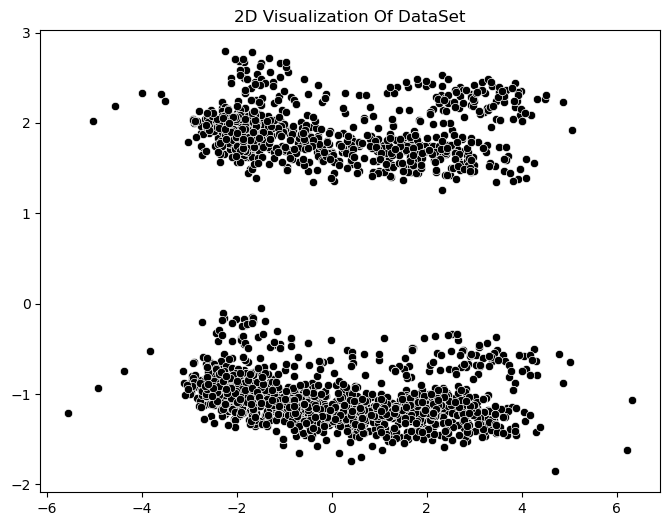

In [40]:
plt.figure(figsize=(8,6))
plt.title("2D Visualization Of DataSet")
sns.scatterplot(x=x_pca[:,0],y=x_pca[:,1],c="black")

In [41]:
pca.explained_variance_ratio_


array([0.23163158, 0.11385454, 0.10405815])

Text(0.5, 0, 'PCA3')

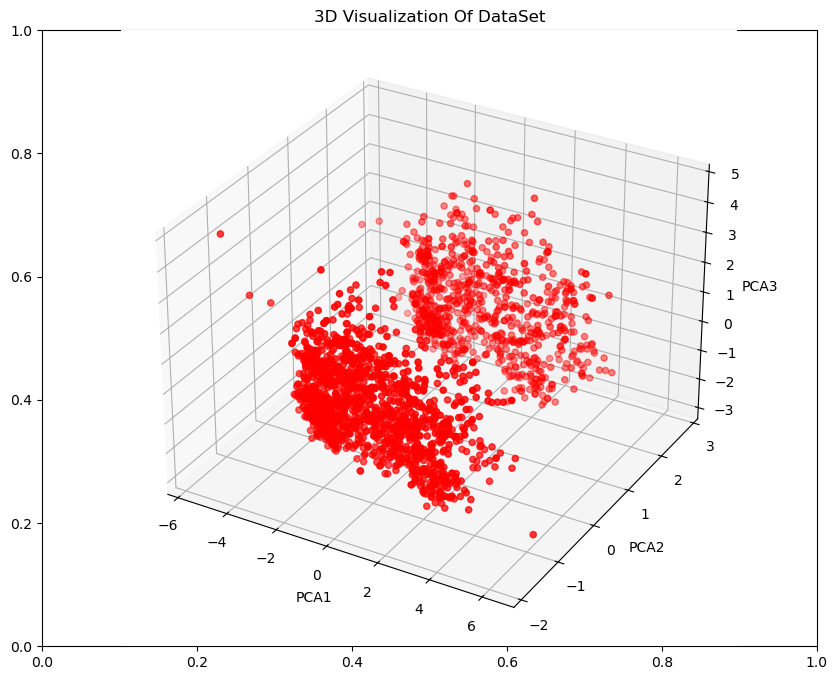

In [42]:
fig=plt.figure(figsize=(10,8))
plt.title("3D Visualization Of DataSet")
ax=fig.add_subplot(111,projection="3d")
ax.scatter(x_pca[:,0],x_pca[:,1],x_pca[:,2],c="red")
ax.set_xlabel("PCA1")
ax.set_ylabel("PCA2")
ax.set_zlabel("PCA3")

# Elbow Method For K

In [70]:
from sklearn.cluster import KMeans
from kneed import KneeLocator
wcss=[]
for k in range(1,11):
    kmeans=KMeans(n_clusters=k,random_state=42)
    labels=kmeans.fit_predict(x_pca)
    wcss.append(kmeans.inertia_)
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

In [44]:
knee=KneeLocator(range(1,11),wcss,curve="convex",direction="decreasing")
optimal_k=knee.elbow
print(f"Optimal k : {optimal_k}")

Optimal k : 4


<Figure size 800x600 with 0 Axes>

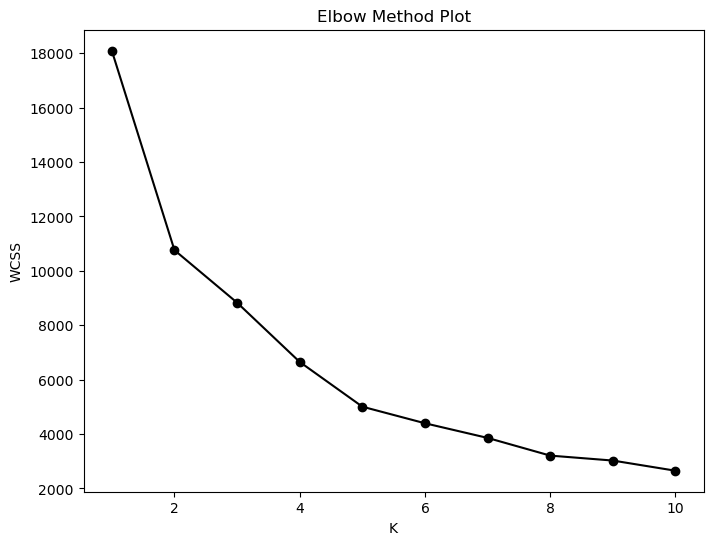

<Figure size 800x600 with 0 Axes>

In [45]:
plt.figure(figsize=(8,6))
plt.plot(range(1,11),wcss,marker="o",c="black")
plt.xlabel("K")
plt.ylabel("WCSS")
plt.title("Elbow Method Plot")
plt.figure(figsize=(8,6))

# Silhouette Score For K 

In [46]:
from sklearn.metrics import silhouette_score
scores=[]
for k in range(2,11):
    kmeans=KMeans(n_clusters=k,random_state=42)
    labels=kmeans.fit_predict(x_pca)
    scores.append(silhouette_score(x_pca,labels))   


<Figure size 800x600 with 0 Axes>

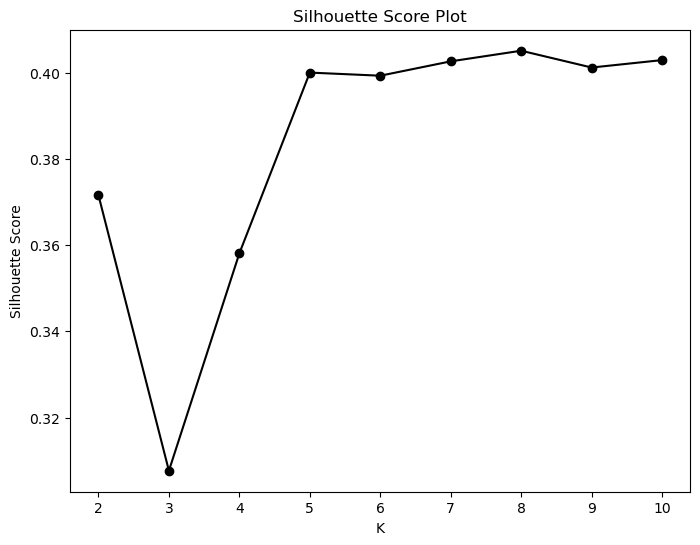

<Figure size 800x600 with 0 Axes>

In [47]:
plt.figure(figsize=(8,6))
plt.plot(range(2,11),scores,marker="o",c="black")
plt.xlabel("K")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score Plot")
plt.figure(figsize=(8,6))

Text(0.5, 1.0, 'Elbow Method & Silhouette Score Combined Plot')

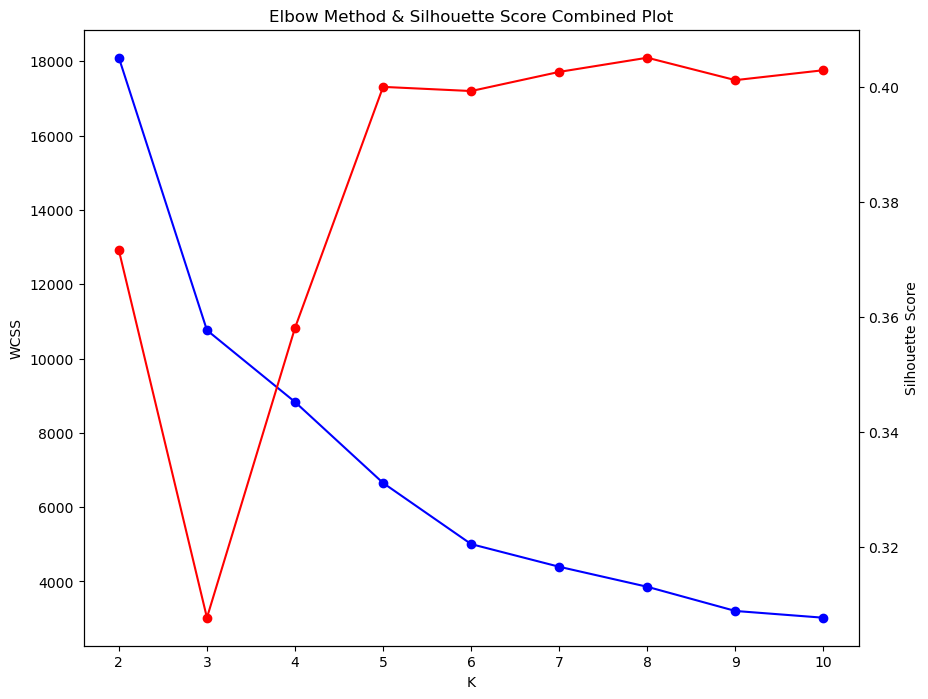

In [48]:
k_range=range(2,11)
fig,ax1=plt.subplots(figsize=(10,8))
ax1.plot(k_range,wcss[:len(k_range)],marker="o",color="blue")
ax1.set_xlabel("K")
ax1.set_ylabel("WCSS")
ax2=ax1.twinx()
ax2.plot(k_range,scores[:len(k_range)],marker="o",color="red")
ax2.set_ylabel("Silhouette Score")
plt.title("Elbow Method & Silhouette Score Combined Plot")

# K-Means Clustering


In [82]:
kmeans=KMeans(n_clusters=4,random_state=42)
kmeans_labels=kmeans.fit_predict(x_pca)

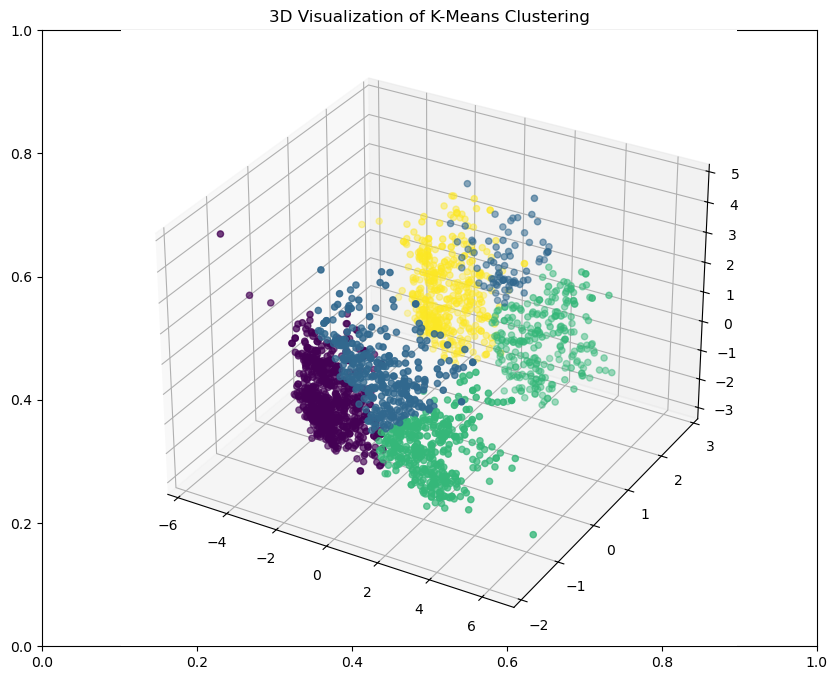

In [50]:
fig=plt.figure(figsize=(10,8))
plt.title("3D Visualization of K-Means Clustering")
ax=fig.add_subplot(111,projection="3d")
ax.scatter(x_pca[:,0],x_pca[:,1],x_pca[:,2],c=kmeans_labels)

# Agglomerative Clustering

In [51]:
from sklearn.cluster import AgglomerativeClustering

In [52]:
agg_clf=AgglomerativeClustering(n_clusters=4,linkage="ward")
agg_labels=agg_clf.fit_predict(x_pca)

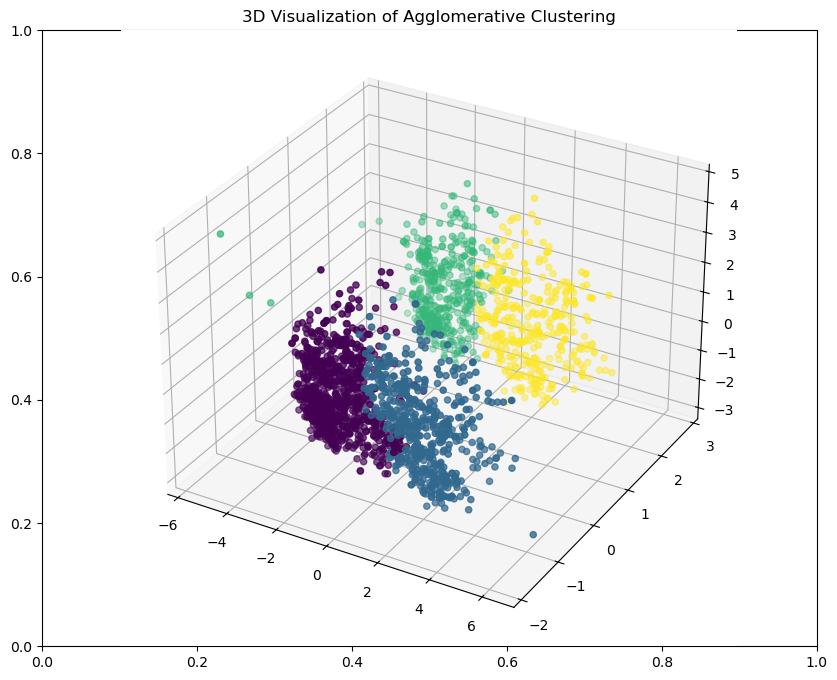

In [53]:
fig=plt.figure(figsize=(10,8))
plt.title("3D Visualization of Agglomerative Clustering")
ax=fig.add_subplot(111,projection="3d")
ax.scatter(x_pca[:,0],x_pca[:,1],x_pca[:,2],c=agg_labels)

# Characterization of Clusters

In [54]:
x["Clusters"]=agg_labels

In [55]:
x.head()

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_Spending,Total_Children,Education_Graduate,Education_Postgraduate,Education_Undergraduate,Living_With_Alone,Living_With_Partner,Clusters
0,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,1.0,0.0,0.0,1.0,0.0,3
1,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,1.0,0.0,0.0,1.0,0.0,2
2,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,1.0,0.0,0.0,0.0,1.0,1
3,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,1.0,0.0,0.0,0.0,1.0,0
4,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,0.0,1.0,0.0,0.0,1.0,0


<Axes: title={'center': 'Frequency Of Clusters'}, xlabel='Clusters', ylabel='count'>

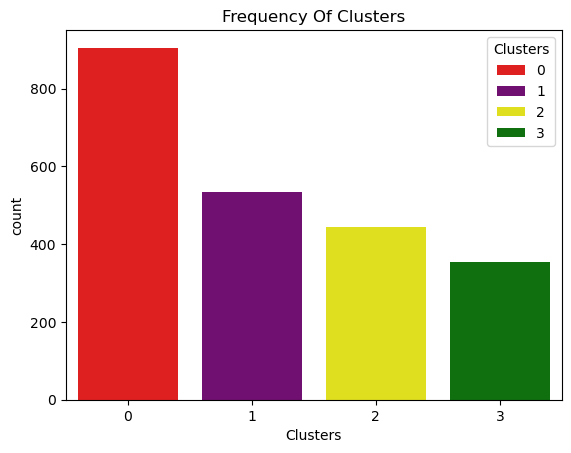

In [56]:
pal=["red","purple","yellow","green"]
plt.title("Frequency Of Clusters")
sns.countplot(x=x["Clusters"],palette=pal,hue=x["Clusters"])

<Axes: title={'center': 'Income v/s Total Spending'}, xlabel='Total_Spending', ylabel='Income'>

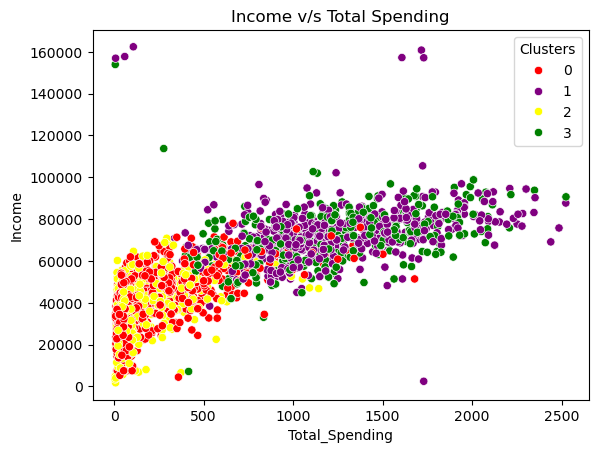

In [57]:
plt.title("Income v/s Total Spending")
sns.scatterplot(x=x["Total_Spending"],y=x["Income"],hue=x["Clusters"],palette=pal)

In [58]:
print("Customers in cluster 0 have low to moderate income, and low to moderate spending")
print("Customers in cluster 1 have high income, and high spending")
print("Customers in cluster 2 have low  income, and low spending")
print("Customers in cluster 3 have moderate to high income, and high spending")

Customers in cluster 0 have low to moderate income, and low to moderate spending
Customers in cluster 1 have high income, and high spending
Customers in cluster 2 have low  income, and low spending
Customers in cluster 3 have moderate to high income, and high spending


In [59]:
cluster_summary=x.groupby("Clusters").mean()

In [60]:
print(cluster_summary)


                Income    Recency  NumDealsPurchases  NumWebPurchases  \
Clusters                                                                
0         39680.580110  48.914917           2.594475         3.153591   
1         72808.445693  49.202247           1.958801         5.687266   
2         36960.143018  48.319820           2.594595         2.713964   
3         70722.681303  50.504249           1.855524         5.790368   

          NumCatalogPurchases  NumStorePurchases  NumWebVisitsMonth  Complain  \
Clusters                                                                        
0                    0.969061           4.143646           6.307182  0.011050   
1                    5.498127           8.659176           3.580524  0.005618   
2                    0.837838           3.623874           6.659910  0.011261   
3                    5.014164           8.430595           3.728045  0.005666   

          Response        Age  Customer_Tenure_Days  Total_Spending  \
Clu

In [62]:
import joblib
import os

In [64]:
joblib.dump(kmeans, '../models/kmeans_model.pkl')
joblib.dump(agg_clf, '../models/aggl_model.pkl')

['../models/aggl_model.pkl']

In [66]:
joblib.dump(scaler, '../models/scaler.pkl')
joblib.dump(ohe, '../models/encoder.pkl')

['../models/encoder.pkl']

In [71]:
print(type(kmeans))
print(kmeans.n_clusters)

<class 'sklearn.cluster._kmeans.KMeans'>
10


In [72]:
print(x.columns.tolist())

['Income', 'Recency', 'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth', 'Complain', 'Response', 'Age', 'Customer_Tenure_Days', 'Total_Spending', 'Total_Children', 'Education_Graduate', 'Education_Postgraduate', 'Education_Undergraduate', 'Living_With_Alone', 'Living_With_Partner', 'Clusters']


In [78]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Drop the Clusters column from features
x_clean = x.drop(columns=['Clusters'])
print("Clean feature columns:", x_clean.columns.tolist())
print("Shape:", x_clean.shape)

# Retrain KMeans on clean features
# Use 4 clusters to match aggl (makes comparison meaningful)
kmeans_clean = KMeans(n_clusters=4, random_state=42, n_init=10)
kmeans_clean.fit(x_clean)

print("KMeans retrained successfully!")
print("Cluster distribution:", pd.Series(kmeans_clean.labels_).value_counts())

Clean feature columns: ['Income', 'Recency', 'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth', 'Complain', 'Response', 'Age', 'Customer_Tenure_Days', 'Total_Spending', 'Total_Children', 'Education_Graduate', 'Education_Postgraduate', 'Education_Undergraduate', 'Living_With_Alone', 'Living_With_Partner']
Shape: (2236, 18)
KMeans retrained successfully!
Cluster distribution: 3    689
1    653
0    500
2    394
Name: count, dtype: int64


In [ ]:
customers_data_scored = customers_data_cleaned.copy()
customers_data_scored["kmeans_labels"] = kmeans_labels
customers_data_scored["agg_labels"] = agg_labels

kmeans_profiles = customers_data_scored.groupby("kmeans_labels").mean(numeric_only=True).round(2)
agg_profiles = customers_data_scored.groupby("agg_labels").mean(numeric_only=True).round(2)

print("=== KMeans Profiles ===")
print(kmeans_profiles[["Income", "Total_Spending", "Age", "Recency", "Total_Children", "NumWebPurchases", "NumStorePurchases"]])
print("\n=== Agglomerative Profiles ===")
print(agg_profiles[["Income", "Total_Spending", "Age", "Recency", "Total_Children", "NumWebPurchases", "NumStorePurchases"]])

KeyError: 'kmeans_labels'

In [ ]:
from pathlib import Path
import joblib

models_dir = Path("../models")
models_dir.mkdir(parents=True, exist_ok=True)

joblib.dump(pca, models_dir / "pca.pkl")
joblib.dump(list(x.columns), models_dir / "feature_columns.pkl")

print("Saved PCA and feature metadata for Streamlit inference.")